# DeepDISC Formatted DP1 Data

Before perusing this notebook, take a look at the `DP1_Access.ipynb` to understand what DP1 data is and what subset of DP1 we are grabbing. `DP1_Access.ipynb` creates **three main data products per patch**:

### 1. Image Cutouts (`.npy` files)
- **Format**: NumPy array 
- **Shape**: `(6, 3400, 3400)` - 6 bands × 3400 pixels × 3400 pixels
- **Bands**: u, g, r, i, z, y (LSST photometric bands)
- **Filename pattern**: `full_p{patch_id}.npy`
- **Example**: `full_p24.npy`, `full_p25.npy`, etc.

### 2. Object Catalogs (`.json` files)
- **Format**: JSON (pandas DataFrame exported as records)
- **Filename pattern**: `full_p{patch_id}.json`
- **Example**: `full_p24.json`, `full_p25.json`, etc.

Catalog Columns (32 total):
- **Positional**: `coord_ra`, `coord_dec`, `cutout_x`, `cutout_y` (pixels, origin at bottom-left)
- **Identifiers**: `objectId`, `parentObjectId`, `tract`, `patch`
- **Morphology**: `refExtendedness`, `shape_xx`, `shape_xy`, `shape_yy`
- **Reference info**: `refBand`, `x`, `y`
- **Deblending flags**: `i_blendedness`, `deblend_failed`, `deblend_skipped`, `deblend_nChild`, `detect_fromBlend`, `detect_isIsolated`, `detect_isDeblendedModelSource`
- **Photometry** (12 columns): For each band (u, g, r, i, z, y):
  - `{band}_cModelFlux`
  - `{band}_cModelFluxErr`
- **Derived**: `mag_u`, `mag_g`, `mag_r`, `mag_i`, `mag_z`, `mag_y`

**Filtering Applied**:
 - Only primary detections (`deblend_nChild == 0`)
 - Objects within patch boundaries
 - Spatial overlap with HST CANDELS GOODS-S footprint

**Photometric Calibration**:
 - Zero point: 31.4 mag
 - Fluxes in nanomaggies
 - Magnitudes computed as: `mag = 31.4 - 2.5 * log10(flux)`

### 3. WCS Headers (`wcs_dp1.json`)
- **Format**: Single JSON file containing WCS information for all patches
- **Structure**: Dictionary with patch IDs as keys
- **Content**: FITS header metadata for coordinate transformations
- **Location**: `/global/homes/y/yaswante/wcs_dp1.json`

## File/Folder Structure

```
/global/homes/y/yaswante/
├── full_p24.npy          # Image cutout for patch 24 (6 bands)
├── full_p24.json         # Object catalog for patch 24
├── full_p25.npy          # Image cutout for patch 25
├── full_p25.json         # Object catalog for patch 25
├── full_p34.npy          # Image cutout for patch 34
├── full_p34.json         # Object catalog for patch 34
├── full_p35.npy          # Image cutout for patch 35
├── full_p35.json         # Object catalog for patch 35
├── full_p44.npy          # Image cutout for patch 44
├── full_p44.json         # Object catalog for patch 44
├── full_p45.npy          # Image cutout for patch 45
├── full_p45.json         # Object catalog for patch 45
├── wcs_dp1.json          # WCS headers for all patches
└── lsst_dets_hst.json    # Master catalog (all patches combined)
```
The final data represents LSST DP1 detections matched to HST coverage in the GOODS-South field. 

This following notebook will demonstrate how I cut the 6 patches of tract 5063 from DP1 (24, 25, 34, 35, 44, 45) that overlap with the HST objects into 128x128 cutouts. 

### Note

The catalog files that were previously saved were heavily cut based on the filters and overlap with HST images.  

If you want to produce annotations using the scarlet models, I recommend not filtering the patch catalogs as much.  For each patch, just query with  
```python
dataId = {'band': 'i', 'skymap': 'lsst_cells_v1', 'tract': tract, 'patch': patch}
patch_catalog = butler.get("object", dataId, parameters={'columns': col_list})
```


If you use the filtered catalogs previously saved, there will be many cutouts without any annotations!


# Imports

In [1]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.visualization import AsinhStretch, ImageNormalize

from lsst.daf.butler import Butler
import lsst.scarlet.lite as sl
import lsst.meas.extensions.scarlet as mes
from lsst.afw.image import ExposureF
from lsst.afw.image import MultibandExposure
import lsst.geom as geom


def asinh_norm(data, a=0.1):
    finite_data = data[np.isfinite(data)] # ensure no NaN or inf vals
    if len(finite_data) == 0:
        return ImageNormalize(vmin=0, vmax=1, stretch=AsinhStretch(a=a))
    # percentile-based limits
    vmin, vmax = np.percentile(finite_data, [1, 99])
    return ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(a=a))

In [2]:
all_wcs = json.load(open('/home/g4merz/DATA/wcs_dp1.json', 'r'))

# Visualizing Patches

In [3]:
BANDS = {'u': 0, 'g': 1, 'r': 2, 'i': 3, 'z': 4, 'y': 5}
chosen_band = 'i'  # example band to visualize
def load_img(patch_id, band='i'):
    data = np.load(f'/home/g4merz/DATA/full_p{patch_id}.npy')  # (6, H, W)
    return data[BANDS[band]]
patch_ids = [34, 35]
imgs = {pid: load_img(pid, band=chosen_band) for pid in patch_ids}

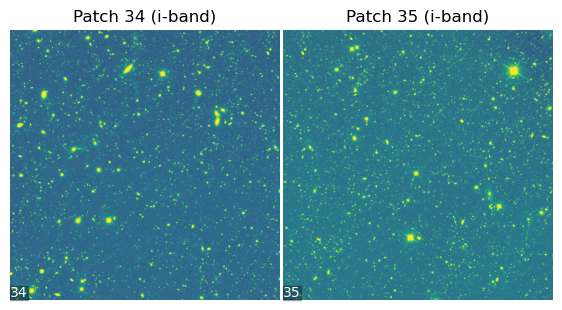

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(7, 7), sharex=True, sharey=True, gridspec_kw={'wspace': 0.01, 'hspace': 0.01})
for idx, (pid, img) in enumerate(imgs.items()):
    ax = axes[idx]
    ax.set_title(f'Patch {pid} ({chosen_band}-band)')
    ax.imshow(img, norm=asinh_norm(img, a=0.1), origin='lower', cmap='viridis')
    ax.text(5, 5, f'{pid}', color='white', fontsize=10,
        ha='left', va='bottom', bbox=dict(facecolor='black', alpha=0.3, pad=0.01))
    ax.axis('off')
# fig.suptitle(f'LSST {chosen_band}-band Coadds for Overlapping Patches', fontsize=16)

As you can see, our patches have some overlap on the right side of the patch. The two bright galaxies in the middle right of Patch 34 also exist in Patch 35. This overlap exists with all 6 patches. Thus, we ensure that our cutouts have no overlapping pixels by only taking the center of the patch so objects aren't repeated in our catalogs. Before we do that, let's find out how many pixels actually do overlap.

## How much Overlap between Patches?

In [5]:
ny34, nx34 = imgs[34].shape
ny35, nx35 = imgs[35].shape
w34, w35 = WCS(all_wcs['34']), WCS(all_wcs['35'])
# 1. Corners of each patch in pixel coords
corners34_pix = np.array([
    [0,       0      ],
    [nx34-1,  0      ],
    [nx34-1,  ny34-1 ],
    [0,       ny34-1 ]
])
corners35_pix = np.array([
    [0,       0      ],
    [nx35-1,  0      ],
    [nx35-1,  ny35-1 ],
    [0,       ny35-1 ]
])
# 2. Convert corners to sky (RA, Dec)
corners34_sky = w34.pixel_to_world(corners34_pix[:,0], corners34_pix[:,1])
corners35_sky = w35.pixel_to_world(corners35_pix[:,0], corners35_pix[:,1])
# 3. Bounding box in sky coordinates (ICRS)
ra34 = corners34_sky.ra.wrap_at(180*u.deg)
dec34 = corners34_sky.dec
ra35 = corners35_sky.ra.wrap_at(180*u.deg)
dec35 = corners35_sky.dec

ra_min_34, ra_max_34 = ra34.min(), ra34.max()
dec_min_34, dec_max_34 = dec34.min(), dec34.max()
ra_min_35, ra_max_35 = ra35.min(), ra35.max()
dec_min_35, dec_max_35 = dec35.min(), dec35.max()

# 4. Overlap box in sky
ra_min_overlap = np.maximum(ra_min_34, ra_min_35)
ra_max_overlap = np.minimum(ra_max_34, ra_max_35)
dec_min_overlap = np.maximum(dec_min_34, dec_min_35)
dec_max_overlap = np.minimum(dec_max_34, dec_max_35)

if (ra_max_overlap <= ra_min_overlap) or (dec_max_overlap <= dec_min_overlap):
    print("No sky overlap detected between patches 34 and 35")
else:
    # 5. Sample the overlap box corners in sky
    overlap_corners_sky = SkyCoord(
        ra=[ra_min_overlap, ra_max_overlap, ra_max_overlap, ra_min_overlap],
        dec=[dec_min_overlap, dec_min_overlap, dec_max_overlap, dec_max_overlap],
        frame='icrs'
    )
    # 6. Convert overlap corners back to each patch's pixel coords
    ox34_x, ox34_y = w34.world_to_pixel(overlap_corners_sky)
    ox35_x, ox35_y = w35.world_to_pixel(overlap_corners_sky)
    # Pixel bounding box for overlap in each image
    x34_min, x34_max = ox34_x.min(), ox34_x.max()
    y34_min, y34_max = ox34_y.min(), ox34_y.max()
    x35_min, x35_max = ox35_x.min(), ox35_x.max()
    y35_min, y35_max = ox35_y.min(), ox35_y.max()
    # 7. Clip to image bounds and compute integer sizes for patch 34
    x34_min_i = max(int(np.floor(x34_min)), 0)
    x34_max_i = min(int(np.ceil(x34_max)), nx34)
    y34_min_i = max(int(np.floor(y34_min)), 0)
    y34_max_i = min(int(np.ceil(y34_max)), ny34)
    width34  = x34_max_i - x34_min_i
    height34 = y34_max_i - y34_min_i
    n_pix34  = max(width34, 0) * max(height34, 0)
    
    # 8. Clip to image bounds and compute integer sizes for patch 35
    x35_min_i = max(int(np.floor(x35_min)), 0)
    x35_max_i = min(int(np.ceil(x35_max)), nx35)
    y35_min_i = max(int(np.floor(y35_min)), 0)
    y35_max_i = min(int(np.ceil(y35_max)), ny35)
    width35  = x35_max_i - x35_min_i
    height35 = y35_max_i - y35_min_i
    n_pix35  = max(width35, 0) * max(height35, 0)

    print("="*70)
    print("OVERLAP ANALYSIS: Patches 34 and 35")
    print("="*70)
    print(f"\nPatch 34 ({nx34}×{ny34} pixels):")
    print(f"  Overlap region: x=[{x34_min_i}, {x34_max_i}), y=[{y34_min_i}, {y34_max_i})")
    print(f"  Overlap dimensions: {width34} × {height34} pixels")
    print(f"  Total overlap pixels: {n_pix34:,}")
    print(f"  Fraction of patch 34: {100*n_pix34/(nx34*ny34):.1f}%")
    print(f"  --> Right edge: last {width34} columns overlap with patch 35")
    
    print(f"\nPatch 35 ({nx35}×{ny35} pixels):")
    print(f"  Overlap region: x=[{x35_min_i}, {x35_max_i}), y=[{y35_min_i}, {y35_max_i})")
    print(f"  Overlap dimensions: {width35} × {height35} pixels")
    print(f"  Total overlap pixels: {n_pix35:,}")
    print(f"  Fraction of patch 35: {100*n_pix35/(nx35*ny35):.1f}%")
    print(f"  --> Left edge: first {width35} columns overlap with patch 34")
    
    print(f"\nOverlap summary:")
    print(f"  Width: {width34} pixels ({width34:.1f} px ≈ {width34/2:.0f} px per edge)")
    print(f"  Height: {height34} pixels (full image height)")
    print(f"\nCONCLUSION: Soo, we should exclude 200 px from each edge to avoid this overlap and have a core region.")

OVERLAP ANALYSIS: Patches 34 and 35

Patch 34 (3400×3400 pixels):
  Overlap region: x=[2999, 3400), y=[0, 3400)
  Overlap dimensions: 401 × 3400 pixels
  Total overlap pixels: 1,363,400
  Fraction of patch 34: 11.8%
  --> Right edge: last 401 columns overlap with patch 35

Patch 35 (3400×3400 pixels):
  Overlap region: x=[0, 400), y=[0, 3400)
  Overlap dimensions: 400 × 3400 pixels
  Total overlap pixels: 1,360,000
  Fraction of patch 35: 11.8%
  --> Left edge: first 400 columns overlap with patch 34

Overlap summary:
  Width: 401 pixels (401.0 px ≈ 200 px per edge)
  Height: 3400 pixels (full image height)

CONCLUSION: Soo, we should exclude 200 px from each edge to avoid this overlap and have a core region.


## Core Region and Cutout Grid

Text(0.5, 0.75, 'Patches 34,35 (i-band) with core region (no 200px overlap)')

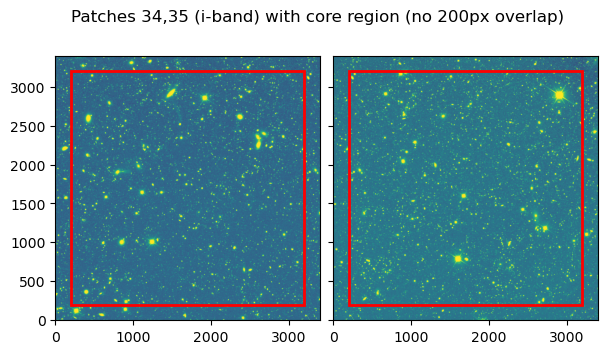

In [6]:
overlap_pixels = 200
h, w = imgs[34].shape
usable_width = w - 2 * overlap_pixels
usable_height = h - 2 * overlap_pixels
start_x, start_y = overlap_pixels, overlap_pixels

fig, axes = plt.subplots(1, 2, figsize=(7, 7), sharex=True, sharey=True, gridspec_kw={'wspace': 0.05, 'hspace': 0.3})
for idx, (pid, img) in enumerate(imgs.items()):
    ax = axes[idx]
    ax.imshow(img, norm=asinh_norm(img, a=0.1), origin='lower', cmap='viridis')
    rect = plt.Rectangle((start_x, start_y),
                     usable_width, usable_height,
                     edgecolor='red', facecolor='none', lw=2)
    ax.add_patch(rect)
fig.suptitle(f"Patches {','.join(str(pid) for pid in patch_ids)} ({chosen_band}-band) with core region (no 200px overlap)", y=0.75)
    # ax.axis('off')
# show core region and then how many cutouts for each patch
# inset of a single cutout from patch 34

Since the model we will use was trained on LSST DC2 simulated images of size 160, let's try to stick to a size close to 160. We'll go with 128x128. Then, how many cutouts will we have given we want cutouts of size 128x128?

Text(0.5, 1.0, 'Patch 34 with 23x23 cutout grid')

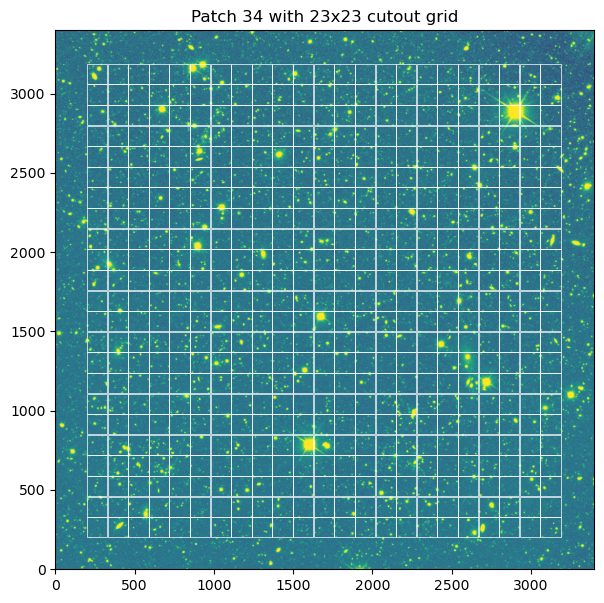

In [7]:
pid = 34
cutout_size = 128
h, w = imgs[pid].shape
# only use the core region avoiding 200px overlap on each edge
usable_width = w - 2 * overlap_pixels # 3000
usable_height = h - 2 * overlap_pixels # 3000
start_x, start_y = overlap_pixels, overlap_pixels # 200, 200
nx_cutouts = usable_width // cutout_size # 3000 // 128 = 23
ny_cutouts = usable_height // cutout_size # 3000 // 128 = 23
# calc spacing to distribute cutouts evenly
if nx_cutouts > 1:
    x_spacing = (usable_width - cutout_size) // (nx_cutouts - 1)
else:
    x_spacing = 0
if ny_cutouts > 1:
    y_spacing = (usable_height - cutout_size) // (ny_cutouts - 1)
else:
    y_spacing = 0

centers = []
for i in range(ny_cutouts):
    for j in range(nx_cutouts):
        if ny_cutouts == 1:
            y_center = start_y + cutout_size // 2
        else:
            y_center = start_y + cutout_size // 2 + i * y_spacing

        if nx_cutouts == 1:
            x_center = start_x + cutout_size // 2
        else:
            x_center = start_x + cutout_size // 2 + j * x_spacing
        centers.append((x_center, y_center))

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img, norm=asinh_norm(img, a=0.1), origin='lower', cmap='viridis')
for (xc, yc) in centers:
    rect = plt.Rectangle((xc - cutout_size//2, yc - cutout_size//2),
                         cutout_size, cutout_size,
                         edgecolor='white', facecolor='none', lw=0.5)
    ax.add_patch(rect)

ax.set_title(f'Patch {pid} with {nx_cutouts}x{ny_cutouts} cutout grid')

Great! So, we'll have 23x23 = 529 cutouts per patch if we have a cutout size of 128x128 pixels. With 6 patches, we'll have a total of 3174 cutouts. Now, let's move on to actually create all of these cutouts and save them to disk.

# Cutout and Catalog Creation

From `DP1_Access.ipynb`, we know the DP1 data that overlaps with HST
is in a single tract within 6 patches. So, we'll just create a folder for each 
patch called `p{patch_id}` and save each patch's cutout within this folder. Because we won't have that many cutouts (~3k), we can just save each cutout's metadata in a single file called `test.json`. This will contain at minimum the filename, height and width of the cutout, patch the cutout belongs to and the cutout's WCS. The final folder structure should look like this:

```
dp1/
├── p24/
├── p25/
├── p34/
├── p35/
├── p44/
├── p45/
├── prep_dp1_for_dd.ipynb
├── prep_dp1_for_dd.py
├── deepdisc_dp1.ipynb
├── dp1.ipynb
├── full_p24.json
├── full_p24.npy
├── full_p25.json
├── full_p25.npy
├── full_p34.json
├── full_p34.npy
├── full_p35.json
├── full_p35.npy
├── full_p44.json
├── full_p44.npy
├── full_p45.json
├── full_p45.npy
├── lsst_dets_hst.json
├── test.json
└── wcs_dp1.json
```


## Single Cutout

Let's write a function for a single cutout within a patch.

In [8]:
def create_single_cutout(patch_id, row, col, w, cutout_size=128):
    patch_cutout = f'/home/g4merz/DATA/full_p{patch_id}.npy'
    full_img_data = np.load(patch_cutout)
    coadd_size = full_img_data.shape[1:] 
    overlap_pixels = 200
    # only use the core region avoiding 200px overlap on each edge
    usable_width = coadd_size[1] - 2 * overlap_pixels  # 3000
    usable_height = coadd_size[0] - 2 * overlap_pixels  # 3000
    start_x, start_y = overlap_pixels, overlap_pixels  # 200, 200
    
    nx_cutouts = usable_width // cutout_size # 3000 // 128 = 23
    ny_cutouts = usable_height // cutout_size # 3000 // 128 = 23
        
    # calc spacing to distribute cutouts evenly
    if nx_cutouts > 1:
        x_spacing = (usable_width - cutout_size) // (nx_cutouts - 1)
    else:
        x_spacing = 0
    
    if ny_cutouts > 1:
        y_spacing = (usable_height - cutout_size) // (ny_cutouts - 1)
    else:
        y_spacing = 0
    
    #     print(f"Creating cutouts for {ra_dec[0]}_{ra_dec[1]}...")
    print(f"Image size: {coadd_size[1]}x{coadd_size[0]}")
    print(f"Usable region: {usable_width}x{usable_height} (starting at {start_x},{start_y})")
    print(f"Cutouts: {nx_cutouts}x{ny_cutouts} = {nx_cutouts * ny_cutouts} total")
    print(f"Spacing: x={x_spacing}, y={y_spacing}")
    # cutout center pos
    # for this example, just select the center cutout
    if ny_cutouts == 1:
        y_center = start_y + cutout_size // 2
    else:
        y_center = start_y + cutout_size // 2 + row * y_spacing
    
    if nx_cutouts == 1:
        x_center = start_x + cutout_size // 2
    else:
        x_center = start_x + cutout_size // 2 + col * x_spacing
    
    cutout_id = row * nx_cutouts + col
    # full_cutout_path = f'p{patch_id}/full_c{cutout_id}.npy'
    # if not os.path.exists(full_cutout_path):
    # all 6 bands
    raw_cutout_u = Cutout2D(full_img_data[0, :, :], position=(x_center, y_center), 
                            size=cutout_size, wcs=w, mode='partial', fill_value=0)
    raw_cutout_g = Cutout2D(full_img_data[1, :, :], position=(x_center, y_center), 
                            size=cutout_size, wcs=w, mode='partial', fill_value=0)
    raw_cutout_r = Cutout2D(full_img_data[2, :, :], position=(x_center, y_center), 
                            size=cutout_size, wcs=w, mode='partial', fill_value=0)
    raw_cutout_i = Cutout2D(full_img_data[3, :, :], position=(x_center, y_center), 
                            size=cutout_size, wcs=w, mode='partial', fill_value=0)
    raw_cutout_z = Cutout2D(full_img_data[4, :, :], position=(x_center, y_center), 
                            size=cutout_size, wcs=w, mode='partial', fill_value=0)
    raw_cutout_y = Cutout2D(full_img_data[5, :, :], position=(x_center, y_center), 
                            size=cutout_size, wcs=w, mode='partial', fill_value=0)
    full_raw_cutout = np.stack((
        raw_cutout_u.data,
        raw_cutout_g.data,
        raw_cutout_r.data,
        raw_cutout_i.data,
        raw_cutout_z.data,
        raw_cutout_y.data
    ))
    # np.save(full_cutout_path, full_raw_cutout)
    return full_raw_cutout, raw_cutout_i.wcs, cutout_id
    # we can get the wcs by doing raw_cutout_i.wcs.to_header_string()
    # wcs_header = raw_cutout_i.wcs.to_header_string()
    # with open(f'p{patch_id}/wcs_c{counter}.wcs', 'w') as f:
    #     f.write(wcs_header)

In [9]:
pid = 34
# pid = 35
row, col = 11, 11
# row, col = 0, 12
wcs34 = WCS(all_wcs[str(pid)])
# change this if you want larger/smaller cutouts, but 128 is good for the DeepDISC model trained on 160x160 simulated LSST data
cutout_size = 128
cutout, cutout_wcs, cid = create_single_cutout(pid, row, col, wcs34, cutout_size=cutout_size)

Image size: 3400x3400
Usable region: 3000x3000 (starting at 200,200)
Cutouts: 23x23 = 529 total
Spacing: x=130, y=130


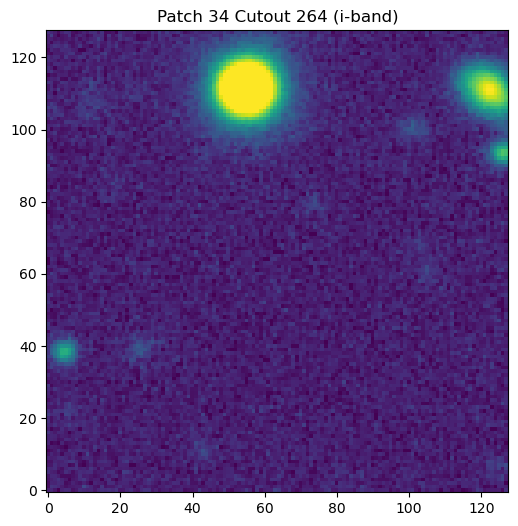

In [10]:
plt.figure(figsize=(6,6))
plt.title(f'Patch {pid} Cutout {cid} (i-band)')
plt.imshow(cutout[3], origin='lower', cmap='viridis', norm=asinh_norm(cutout[3], a=0.1))

## Single Cutout's LSST Pipeline Detection Catalog

Now, let's also cut the LSST Pipeline's detection catalog within this patch using the cutout's WCS.

In [15]:
patch_cat = pd.read_json(f'/home/g4merz/DATA/full_p{pid}.json', orient='records')
patch_cat

,coord_ra,coord_dec,refExtendedness,tract,objectId,parentObjectId,shape_xx,shape_xy,shape_yy,refBand,...,y_cModelFlux,y_cModelFluxErr,mag_u,mag_g,mag_r,mag_i,mag_z,mag_y,cutout_x,cutout_y
0,53.210373,-27.850026,0.0,5063,611255759837079743,611255759837069315,4.354516,0.066300,3.909597,i,...,149947.000000,374.081360,25.001827,22.192844,20.852827,19.408052,18.764172,18.460155,1244.336670,269.385742
1,53.217190,-27.852482,1.0,5063,611255759837079744,611255759837069315,12.543857,-0.734766,8.414174,i,...,38447.613281,574.496277,22.107208,20.934917,20.403015,20.093081,20.019201,19.937826,1135.901731,225.071086
2,53.220334,-27.849735,0.0,5063,611255759837079745,611255759837069315,4.386615,0.058506,3.914943,i,...,8541.523438,326.433380,23.313761,22.367027,21.875982,21.679626,21.623562,21.571161,1085.812128,274.453244
3,53.222632,-27.847632,1.0,5063,611255759837079746,611255759837069315,19.322552,-4.541801,10.574187,i,...,16402.078125,522.391968,22.178425,22.204212,21.416290,21.190453,21.082392,20.862751,1049.194230,312.278784
4,53.218044,-27.847796,1.0,5063,611255759837079749,611255759837069315,10.847188,-4.410918,9.379762,i,...,10379.309570,447.234344,25.202986,24.087864,22.705620,21.995396,21.565598,21.359577,1122.221537,309.413020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11058,53.266683,-27.693604,1.0,5063,611255759837096229,611255759837075967,34.031879,2.714846,9.296775,u,...,215.353363,594.229248,24.492340,27.964493,NaN,29.691166,27.752411,25.567120,344.084194,3083.944318
11059,53.151052,-27.691091,NaN,5063,611255759837096239,611255759837075977,NaN,NaN,NaN,u,...,-100.739861,467.039001,24.442858,NaN,NaN,28.414482,26.157106,NaN,2187.000000,3130.999999
11060,53.151993,-27.690646,NaN,5063,611255759837096240,611255759837075977,NaN,NaN,NaN,u,...,-273.612732,474.300598,24.741779,NaN,NaN,NaN,27.311726,NaN,2172.000000,3139.000000
11061,53.262673,-27.688315,1.0,5063,611255759837096244,611255759837075981,6.624916,-6.002718,73.308266,u,...,1221.904785,711.331604,24.113319,NaN,28.143131,27.316910,28.850651,23.682405,407.854940,3179.246953


In [12]:
cutout_wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 53.08755760368661 -27.520661157024808 
CRPIX : 1570.0 4570.0 
CD1_1 CD1_2  : -5.555555555555553e-05 0.0 
CD2_1 CD2_2  : 0.0 5.5555555555557056e-05 
NAXIS : 128  128

In [14]:
# Convert catalog RA/Dec to pixels using cutout wcs
coords = SkyCoord(ra=patch_cat['coord_ra'].values * u.deg,
                  dec=patch_cat['coord_dec'].values * u.deg)
# When we use Cutout2D, the returned WCS (cutout_wcs) uses a new pixel coordinate system where the cutout's corner is at (0, 0), not the OG image coordinates. Thus, the below world to pixel returns pixel coords in the cutout's coordinate system (0 to 128).
patch_xpix, patch_ypix = cutout_wcs.world_to_pixel(coords)
# Check if within cutout bounds (0 to cutout_size)
in_cutout = ((patch_xpix >= 0) & (patch_xpix < cutout_size) & 
             (patch_ypix >= 0) & (patch_ypix < cutout_size))
cutout_xpix, cutout_ypix = patch_xpix[in_cutout], patch_ypix[in_cutout]
print(f"Found {len(cutout_xpix)} catalog objects in cutout {cid} from Patch {pid}")

Found 22 catalog objects in cutout 264 from Patch 34


In [ ]:
# patch = np.load(f'full_p{pid}.npy')[3]
# plt.figure(figsize=(6,6))
# plt.imshow(patch, origin='lower', cmap='viridis', norm=asinh_norm(patch, a=0.1))
# plt.scatter(patch_cat['cutout_x'], patch_cat['cutout_y'], marker='x', color=['red'], alpha=0.8, label='LSST Pipeline Detections')

plt.figure(figsize=(6,6))
plt.title(f'Patch {pid} Cutout {cid} (i-band)')
plt.imshow(cutout[3], origin='lower', cmap='viridis', norm=asinh_norm(cutout[3], a=0.1))
plt.scatter(cutout_xpix, cutout_ypix, marker='x', color=['red'], alpha=0.8, label='LSST Pipeline Detections')

## Saving All Cutouts and their Metadata from All Patches - With scarlet masks!

The code below will grab the scarlet models for LSST detections within a cutout and produce a segmentation mask from the models

In [2]:
from numpy.typing import DTypeLike
from lsst.scarlet.lite import Box, Blend, Observation


def minimal_data_to_blend(cls, model_psf: np.ndarray, dtype: DTypeLike) -> Blend:

    """Convert the storage data model into a scarlet lite blend

    Parameters
    ----------
    model_psf:
        PSF in model space (usually a nyquist sampled circular Gaussian).
    dtype:
        The data type of the model that is generated.

    Returns
    -------
    blend:
        A scarlet blend model extracted from persisted data.
    """
    model_box = Box(cls.shape, origin=cls.origin)
    observation = Observation.empty(
        bands=cls.bands,
        psfs=cls.psf,
        model_psf=model_psf,
        bbox=model_box,
        dtype=dtype,
    )
    return cls.to_blend(observation)


import lsst.scarlet as scarlet
scarlet.lite.io.ScarletBlendData.minimal_data_to_blend = minimal_data_to_blend


#Need this custom function to add WCS info to the multiband exposure, otherwise it is None
def MultiBandExposure_withWCS(butler,ordered_bands,dtype,dataId):

    """ Produce a MultiBandExposure from the butler, but save WCS info (not default behavior)

    Parameters
    ----------
    butler:
        LSST Butler
    ordered_bands:
        List of the ordered bands, corresponding to the first axis of the image array
    dtype:
        Dataset type to get form the butler, e.g., "deep_coadd"
    dataId:
        dataId containing tract/patch
    Returns
    -------
    mCoadd:
        A MultiBandExposure that has WCS information
    """

    coadds = []
    for b in ordered_bands:
        coadd = butler.get('deep_coadd', band=b,
                         tract=dataId['tract'], patch=dataId['patch'])
        coadds.append(coadd)
    mCoadd = MultibandExposure.fromExposures(ordered_bands, coadds)

    #Add WCS
    for band, exposure in zip(ordered_bands, coadds):
        mCoadd[band].setWcs(exposure.getWcs())
    return mCoadd



In [3]:
def get_segmask(modelData,mCoadd,cutout_bbox,parentId,objectId,mask_source,threshold=None):
    
    #mCoadd_cutout = mCoadd[:,cutout_bbox]
    model_psf = modelData.psf
    if parentId not in modelData.blends.keys():
        print(f'Scarlet blend model is missing parent {parentId} for object {objectId}')
        return np.zeros((cutout_bbox.height,cutout_bbox.width)),0
    
    blend_data = modelData.blends[parentId]
    

    blend = blend_data.minimal_data_to_blend(model_psf[None, :, :], dtype=np.float32)

    #observed_bands = blend_data.bands
    box = sl.Box(blend_data.shape, blend_data.origin)
    blend_bbox = mes.utils.scarletBoxToBBox(box)

    observation = mes.utils.buildObservation(modelPsf=model_psf,
                                         psfCenter=cutout_bbox.getCenter(),
                                         mExposure=mCoadd[:,blend_bbox],
                                         )

    blend = blend_data.to_blend(observation)

    #Grab the index of the object in the blend 
    source_ids = np.array([s.record_id for s in blend.sources])
    blend_source_ind = int(*np.where(source_ids==objectId))  #TODO: check if the objectId does indeed exist in the blend

    blend.conserve_flux()


    source = blend.sources[blend_source_ind]
    source_model = source.get_model()

    flux_model = source.flux_weighted_image
    flux_model = source.flux_weighted_image.project(bbox=blend.bbox)

    convolved_model = source_model.copy().project(bbox=blend.bbox)
    convolved_model = blend.observation.convolve(convolved_model,mode='real')

    
    #make the segmask 
    #either threshold the scarlet model or the flux conserved model above an SNR defined by the observation variance
    mask = np.zeros(flux_model.data.shape[1:])


    if mask_source not in ['scarlet_model','flux_conserved_model']:
        raise NotImplementedError('mask_source must be either scarlet_model or flux_conserved_model')
    
    if mask_source=='scarlet_model':
        if threshold is not None:
            for i in range(convolved_model.n_bands):
                mask+=convolved_model.data[i]>threshold*np.sqrt(observation.variance.data[i])
            mask = mask>0
        else:
            mask = np.max(convolved_model.data, axis=0) != 0
            
    elif mask_source=='flux_conserved_model': 
        if threshold is not None:
            for i in range(flux_model.n_bands):
                mask+=flux_model.data[i]>threshold*np.sqrt(observation.variance.data[i])
            mask = mask>0
        else:
            mask = np.max(flux_model.data, axis=0) != 0

    return mask.astype(int), blend_bbox


def get_bbox(mask):
    """
    Calculates the bounding box of a mask. Returns None if the mask is empty.
    """
    h= mask.shape[0]
    w = mask.shape[1]
    if not np.any(mask):
        print("No bbox because mask is empty!")
        return None
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    #keep inside cutout bounds
    return max(0,rmin-4), min(rmax+4,h), max(0,cmin-4), min(cmax+4,w)


In [18]:
import cv2
from lsst.afw.fits import makeLimitedFitsHeader

def annotate_dp1(imgid,cutout_cat,modelData,mCoadd,cutout_bbox,column_keys,mask_source='scarlet_model',threshold=2):

    record = {}

    custom_cols = {}
        
    record[f"filename"] = f'image_{imgid}'
    record["image_id"] = imgid
    record["height"] = cutout_bbox.height
    record["width"] = cutout_bbox.width
    objs = []

    # Generate segmentation masks for each source from the scarlet models 
    for i in range(len(cutout_cat)):
        #TODO: Group the objects by parent ID for better efficiency

        parentId = cutout_cat['parentObjectId'].iloc[i].astype(np.int64)
        objectId = cutout_cat['objectId'].iloc[i].astype(np.int64)
        
        mask,blend_bbox = get_segmask(modelData,mCoadd,cutout_bbox,parentId,objectId,mask_source=mask_source,threshold=threshold)        
        if np.all(mask==0):
            print(f'Failed to produce mask for source {objectId}')
            continue
        bbox = get_bbox(mask)

        yoff = blend_bbox.minY - cutout_bbox.minY
        xoff = blend_bbox.minX - cutout_bbox.minX

        y0,y1,x0,x1=bbox
        y0+=yoff
        y1+=yoff
        x0+=xoff
        x1+=xoff
        
        w = x1-x0
        h = y1-y0
        
        # https://github.com/facebookresearch/Detectron/issues/100
        contours, hierarchy = cv2.findContours(
            (mask).astype(np.uint8), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
        )
        segmentation = []
        for contour in contours:
            contour = contour.flatten()
            if len(contour) > 4:
                contour[::2] += xoff
                contour[1::2] += yoff
                segmentation.append(contour.tolist())
        # No valid countors
        if len(segmentation) == 0:
            print('No valid contours for mask of object ', i)
            continue

        # Add to dict
        obj = {
            "bbox": [x0, y0, w, h],
            "area": w * h,
            "bbox_mode": 1, # indicates X0,Y0,W,H box
            "segmentation": segmentation,
            "category_id": 0,
            #"redshift": redshifts[i],
            #"obj_id": obj_ids[i],
            #"mag_i": mag_is[i],
        }
    
        if column_keys is not None:
            for col in column_keys:
                obj[col] = cutout_cat[col].iloc[i]

        objs.append(obj)

    return objs


    

In [5]:
butler = Butler("dp1", collections="LSSTComCam/DP1")
skymap = butler.get("skyMap", skymap="lsst_cells_v1")

In [31]:
def create_cutouts(patch_id, tract_id, patch_wcs, mCoadd, modelData,column_keys,cutout_size=128,overlap_pixels=0):
    patch_cutout = f'/home/g4merz/DATA/full_p{patch_id}.npy'
    full_img_data = np.load(patch_cutout)

    # read in patch catalog and then turn coords into SkyCoords
    full_cat = pd.read_json(f'/home/g4merz/DATA/full_p{patch_id}.json', orient='records')
    coords = SkyCoord(ra=full_cat['coord_ra'].values * u.deg,
                      dec=full_cat['coord_dec'].values * u.deg)
    
    coadd_size = full_img_data.shape[1:] 
    
    # avoid the edges by some "overlap" amount
    usable_width = coadd_size[1] - 2 * overlap_pixels  # 3000
    usable_height = coadd_size[0] - 2 * overlap_pixels  # 3000
    start_x, start_y = overlap_pixels, overlap_pixels  # 200, 200
    
    nx_cutouts = usable_width // cutout_size # 3000 // 128 = 23
    ny_cutouts = usable_height // cutout_size # 3000 // 128 = 23
        
    # calc spacing to distribute cutouts evenly
    if nx_cutouts > 1:
        x_spacing = (usable_width - cutout_size) // (nx_cutouts - 1)
    else:
        x_spacing = 0
    
    if ny_cutouts > 1:
        y_spacing = (usable_height - cutout_size) // (ny_cutouts - 1)
    else:
        y_spacing = 0
    
    print(f"Image size: {coadd_size[1]}x{coadd_size[0]}")
    print(f"Usable region: {usable_width}x{usable_height} (starting at {start_x},{start_y})")
    print(f"Cutouts: {nx_cutouts}x{ny_cutouts} = {nx_cutouts * ny_cutouts} total")
    print(f"Spacing: x={x_spacing}, y={y_spacing}")
    
    # List to store metadata for all cutouts
    cutout_md = []
    counter = 0
    for i in range(ny_cutouts):
        for j in range(nx_cutouts):
    #for i in range(10,11):
    #    for j in range(10,11):
            # cutout center pos
            if ny_cutouts == 1:
                y_center = start_y + cutout_size // 2
                y_origin = start_y
            else:
                y_center = start_y + cutout_size // 2 + i * y_spacing
                y_origin = start_y + i * y_spacing
            if nx_cutouts == 1:
                x_center = start_x + cutout_size // 2
                x_origin = start_x
            else:
                x_center = start_x + cutout_size // 2 + j * x_spacing
                x_origin = start_y + i * x_spacing
            
            full_cutout_path = f'/home/g4merz/DATA/p{patch_id}/full_c{counter}.npy'
            
            #if not os.path.exists(full_cutout_path):
            raw_cutout_u = Cutout2D(full_img_data[0], position=(x_center, y_center), 
                                    size=cutout_size, wcs=patch_wcs, mode='partial', fill_value=0)
            raw_cutout_g = Cutout2D(full_img_data[1], position=(x_center, y_center), 
                                    size=cutout_size, wcs=patch_wcs, mode='partial', fill_value=0)
            raw_cutout_r = Cutout2D(full_img_data[2], position=(x_center, y_center), 
                                    size=cutout_size, wcs=patch_wcs, mode='partial', fill_value=0)
            raw_cutout_i = Cutout2D(full_img_data[3], position=(x_center, y_center), 
                                    size=cutout_size, wcs=patch_wcs, mode='partial', fill_value=0)
            raw_cutout_z = Cutout2D(full_img_data[4], position=(x_center, y_center), 
                                    size=cutout_size, wcs=patch_wcs, mode='partial', fill_value=0)
            raw_cutout_y = Cutout2D(full_img_data[5], position=(x_center, y_center), 
                                    size=cutout_size, wcs=patch_wcs, mode='partial', fill_value=0)
            full_raw_cutout = np.stack((
                raw_cutout_u.data,
                raw_cutout_g.data,
                raw_cutout_r.data,
                raw_cutout_i.data,
                raw_cutout_z.data,
                raw_cutout_y.data
            ))
            np.save(full_cutout_path, full_raw_cutout)
            cutout_wcs = raw_cutout_i.wcs
            #else:
                # If cutout already exists, recreate WCS for metadata
             #   raw_cutout_i = Cutout2D(full_img_data[3], position=(x_center, y_center), 
             #                           size=cutout_size, wcs=patch_wcs, mode='partial', fill_value=0)
             #   cutout_wcs = raw_cutout_i.wcs
            
            # Convert catalog RA/Dec to pixels using cutout wcs
            patch_xpix, patch_ypix = cutout_wcs.world_to_pixel(coords)
            # Check if within cutout bounds (0 to cutout_size)
            in_cutout = ((patch_xpix >= 0) & (patch_xpix < cutout_size) & 
                         (patch_ypix >= 0) & (patch_ypix < cutout_size))
            cutout_xpix, cutout_ypix = patch_xpix[in_cutout], patch_ypix[in_cutout]
            n_catalog_objects = len(cutout_xpix)
            overlaps_with_hst = n_catalog_objects > 0

            print(f'{n_catalog_objects} in the patch') 
            #Get the cutout bounding box with coordinates in the original frame 
            cutoutSize = geom.ExtentI(cutout_size, cutout_size)
            patch_xorigin, patch_yorigin = mCoadd.origin  
            bbox_origin = patch_xorigin+x_origin, patch_yorigin+y_origin
            cutout_bbox = geom.BoxI(geom.Point2I((bbox_origin[1], bbox_origin[0])), cutoutSize)
            # Create scarlet masks  
            cutout_cat = full_cat[in_cutout]
            print('Running mask generation')
            annotations = annotate_dp1(counter,cutout_cat,modelData,mCoadd,cutout_bbox,column_keys,mask_source='scarlet_model',threshold=2)
            # Save metadata for this cutout

            metadata = {
                "file_name": full_cutout_path,
                "image_id": counter,
                "height": cutout_size,
                "width": cutout_size,
                "patch": patch_id,
                "tract": tract_id,
                "cutout_id": counter,
                "overlaps_with_hst": overlaps_with_hst,
                "wcs": cutout_wcs.to_header_string(),
                "annotations": annotations
            }
            cutout_md.append(metadata)
            # debug info for first few cutouts
            if counter < 3:
                print(f"  Cutout {counter}: center=({x_center}, {y_center}), "
                      f"objects={n_catalog_objects}")
            
            counter += 1
    
    print(f"Created and saved {counter} cutouts for patch {patch_id}!")    
    return cutout_md

### Run for all patches

Load the MultibandExposure and scarlet models per patch and re-use for cutouts within the same patch.  Loading in the MultibandExposure and scarlet models will take ~30 seconds, but we only need to do this once per patch.  

**Note**: Scarlet models may fail to produce a segmask. This can be for a few reasons.  
a) Sometimes the scarlet models will actually be associated with a different tract/patch dataId.  This is (I think) due to overlapping regions getting split between patches.  This notebook does not account for that effect.  However, the `DP1_cutouts_scarlet_lite.ipynb` code does.  You could try saving the cutouts where scarlet modeling failed and rerunning with an alternative dataId.  
b) The thresholding may not allow any pixels to be passed into the mask.  You could try lowering the threshold  




In [32]:
#This help function lets us not worry about fixing the datatypes for json saving

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NpEncoder, self).default(obj)


In [33]:
#pre-made WCS dict that contains the wcs for each tract and patch
all_wcs = json.load(open('/home/g4merz/DATA/all_wcs_dp1.json', 'r'))


In [34]:
column_keys = ['objectId', 'parentObjectId']
ordered_bands=('u','g','r','i','z','y')

#patch_ids = [24, 25, 34, 35, 44, 45]
patch_ids = [34]
tract=5063
all_cutout_md = []
edge_pixels=250
for patch_id in patch_ids:
    dataId = {'band': 'i', 'skymap': 'lsst_cells_v1', 'tract':tract, 'patch': patch_id}
    print('Loading in MultiBandExposure for ', dataId)
    mCoadd = MultiBandExposure_withWCS(butler,ordered_bands,"deep_coadd",dataId)
    print('Loading in scarlet models for ', dataId)
    modelData = butler.get("object_scarlet_models", dataId=dataId)
    #wcs = WCS(all_wcs[f'{patch_id}'])
    patch_wcs = WCS(all_wcs[f'{tract}'][f'{patch_id}'])
    patch_md = create_cutouts(patch_id, tract, patch_wcs, mCoadd, modelData, column_keys,cutout_size=3400)
    all_cutout_md.extend(patch_md)
    print(f"Total cutouts so far: {len(all_cutout_md)}\n")

# Save all metadata to a single file
with open('/home/g4merz/DATA/test_t5063_p34.json', 'w') as f:
    json.dump(all_cutout_md, f, indent=2,cls=NpEncoder)

print(f"DONE: Saved metadata for {len(all_cutout_md)} cutouts to test.json")

Loading in MultiBandExposure for  {'band': 'i', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 34}
Loading in scarlet models for  {'band': 'i', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 34}
Image size: 3400x3400
Usable region: 3400x3400 (starting at 0,0)
Cutouts: 1x1 = 1 total
Spacing: x=0, y=0
11063 in the patch
Running mask generation


/tmp/ipykernel_5313/766619477.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  blend_source_ind = int(*np.where(source_ids==objectId))  #TODO: check if the objectId does indeed exist in the blend


Failed to produce mask for source 611255759837079810
Failed to produce mask for source 611255759837079811
No valid contours for mask of object  46
No valid contours for mask of object  96
Failed to produce mask for source 611255759837080644
Failed to produce mask for source 611255759837080645
No valid contours for mask of object  184
Failed to produce mask for source 611255759837080650
Failed to produce mask for source 611255759837080651
Failed to produce mask for source 611255759837080652
Failed to produce mask for source 611255759837080801
Failed to produce mask for source 611255759837080828
No valid contours for mask of object  212
Failed to produce mask for source 611255759837080855
No valid contours for mask of object  219
Failed to produce mask for source 611255759837080902
No valid contours for mask of object  244
Failed to produce mask for source 611255759837080953
No valid contours for mask of object  282
Failed to produce mask for source 611255759837081059
Failed to produce m

If you would like to visualize using deepdisc code, run the cells below

You can install DeepDISC on the RSP by following the `RSP_install.md`

In [35]:
from detectron2.data import MetadataCatalog, DatasetCatalog

if 'astro_test' in MetadataCatalog and 'astro_test' in DatasetCatalog:
    DatasetCatalog.remove("astro_test")
    MetadataCatalog.remove("astro_test")

from deepdisc.data_format.register_data import register_data_set
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer
from detectron2.utils.visualizer import ColorMode

from astropy.visualization import make_lupton_rgb

from matplotlib import colors
from deepdisc.astrodet.visualizer import ColorMode
green = np.array(colors.to_rgb('green'))*255
DatasetCatalog.register("astro_test", lambda: get_metadata())
astrotest_metadata = MetadataCatalog.get("astro_test").set(thing_classes=["object"]).set(thing_colors=[green])


Load in one of the saved images and metadata dictionaries

In [36]:
for i,d in enumerate(all_cutout_md):
    if len(d['annotations'])>0:
        print(i)

0


In [37]:
print(len(ddicts))

1


In [38]:
cid=0
image = np.load(f'/home/g4merz/DATA/p{patch_id}/full_c{cid}.npy')
ddicts = json.load(open('/home/g4merz/DATA/test_t5063_p34.json', 'r'))
#ddict = ddicts[cid]
ddict = all_cutout_md[cid]

img = make_lupton_rgb(image[3],image[2],image[1],stretch=15,Q=10)


total instances: 9992


Text(0.5, 1.0, 'Ground Truth')

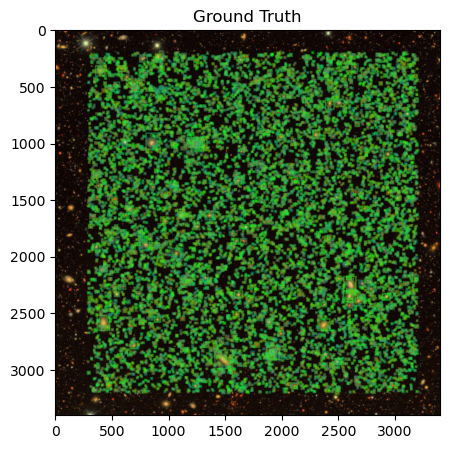

In [39]:
import matplotlib.pyplot as plt
from deepdisc.astrodet.visualizer import Visualizer
from deepdisc.astrodet.visualizer import ColorMode

from astropy.visualization import make_lupton_rgb

plt.figure(figsize=(5,5))


print("total instances:", len(ddict["annotations"]))
v0 = Visualizer(
    img,
    metadata=astrotest_metadata,
    scale=1,
    instance_mode=ColorMode.SEGMENTATION,  # remove the colors of unsegmented pixels. This option is only available for segmentation models
)
groundTruth = v0.draw_dataset_dict(ddict, lf=False, alpha=0.1)

ax1 = plt.subplot(1, 1, 1)
ax1.imshow(groundTruth.get_image())
#ax1.axis("off")
plt.title('Ground Truth')

